<ipython-input-45-3c5d94a5f9ef>:77: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-45-3c5d94a5f9ef>:77: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-45-3c5d94a5f9ef>:77: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-45-3c5d94a5f9ef>:77: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-45-3c5d94a5f9ef>:77: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-45-3c5d94a5f9ef>:77: RuntimeWarning: covariance is not symmetric positive-semide

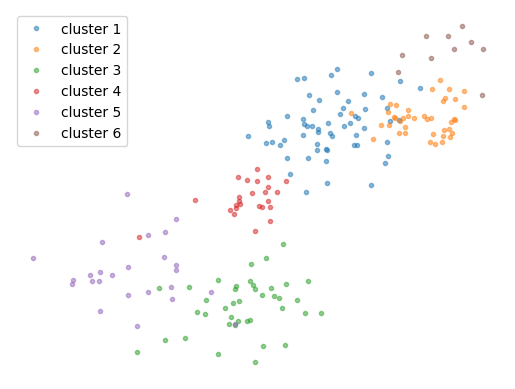

In [45]:
# LINK AL NOTEBOOK: https://colab.research.google.com/drive/1MvIib-nyLaZcHAYzIOwoZrPqAQBcvETM?authuser=1#scrollTo=7RFzPhMJ8rq7
# LINK AL CODICE ORIGINALE: https://h1ros.github.io/posts/make-simulated-data-for-clustering/


# Create the dataset for Lab06 (ed. 2023/24)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# fix the seed, so as to have the same values in the matrix at every run
np.random.seed(1)

# Set the number of objects
N = 200

# Set the dimensionality of the dataset
M = 15

# Generate the 2D matrix with random values (normally distributed)
X = np.random.randn(N,M).round(2)


# 5 imbalanced classes: 1(42), 2(26), 3(26), 4(18), 5(18)   # Lab05
# 5 imbalanced classes: 1(60), 2(40), 3(40), 4(25), 5(25), 6(10)   # Lab06
a1  = np.array( [int(1) for j in range(0, 60)] )
a2  = np.array( [int(2) for j in range(0, 40)] )
a3  = np.array( [int(3) for j in range(0, 40)] )
a4  = np.array( [int(4) for j in range(0, 25)] )
a5  = np.array( [int(5) for j in range(0, 25)] )
a6  = np.array( [int(6) for j in range(0, 10)] )
TRUElabels = np.concatenate( [a1, a2, a3, a4, a5, a6] )

# REF: https://h1ros.github.io/posts/make-simulated-data-for-clustering/
import pandas as pd

# 5 clusters in M-D
cl1_m = np.array( np.random.randint(10, size=(M)) + 2 )
cl2_m = np.array( np.random.randint(10, size=(M)) + 4)
cl3_m = np.array( np.random.randint(10, size=(M)) - 2 )
cl4_m = np.array( np.random.randint(10, size=(M)) + 2 )
cl5_m = np.array( np.random.randint(10, size=(M)) - 4 )
cl6_m = np.array( np.random.randint(10, size=(M)) + 8)

d_means = {'cluster 1': cl1_m,
           'cluster 2': cl2_m,
           'cluster 3': cl3_m,
           'cluster 4': cl4_m,
           'cluster 5': cl5_m,
           'cluster 6': cl6_m}

cl1_c = np.array( np.random.randint(4, size=(M, M)) )
cl2_c = np.array( np.random.randint(2, size=(M, M)) )
cl3_c = np.array( np.random.randint(4, size=(M, M)) )
cl4_c = np.array( np.random.randint(2, size=(M, M)) )
cl5_c = np.array( np.random.randint(5, size=(M, M)) )
cl6_c = np.array( np.random.randint(2, size=(M, M)) )
# print(cl1_m)

d_covs = {'cluster 1': cl1_c,
          'cluster 2': cl2_c,
          'cluster 3': cl3_c,
          'cluster 4': cl4_c,
          'cluster 5': cl5_c,
          'cluster 6': cl6_c}


# Generate data based on the above parameters
n_data = np.array( [60, 40, 40, 25, 25, 10] )

# Generate data based on the above parameters
X = []
l = []
i = 0
for cluster in d_means.keys():
    Ncl = n_data[i]
    i=i+1
    arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
    df_tmp = pd.DataFrame(arr)
    X_tmp = df_tmp.to_numpy()
    if i==1:
      X = X_tmp
    else:
      X = np.concatenate( [X, X_tmp] )
    df_tmp['label'] = cluster
    l.append(df_tmp)
    plt.plot(df_tmp[3], df_tmp[5], '.', label=cluster, alpha=0.5)

plt.legend()
plt.axis('off')
plt.show()

In [47]:
# Shuffle the data points (keeping their true labels)
shuffler = np.random.permutation(N)
X_shuffled = X[shuffler]
TRUElabels_shuffled = TRUElabels[shuffler]

In [48]:
# Save the dataset
np.save("Dataset_lab06.npy", X_shuffled)

In [49]:
# Save TRUE labels
np.save("TRUElabels_lab06.npy", TRUElabels_shuffled)

In [12]:
# Define a palette of colours for the K clusters (useful for the next tasks)
PAL = ['black', 'red', 'green', 'blue', 'yellow', 'orange', 'purple', 'magenta', 'cyan', 'brown']

PCA: explained variation per principal component: [0.7  0.08]

Applying tSNE...


<ipython-input-11-76933469a680>:40: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax1, hue=LABELS, palette=PAL)
<ipython-input-11-76933469a680>:47: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax2, hue=LABELS, palette=PAL)


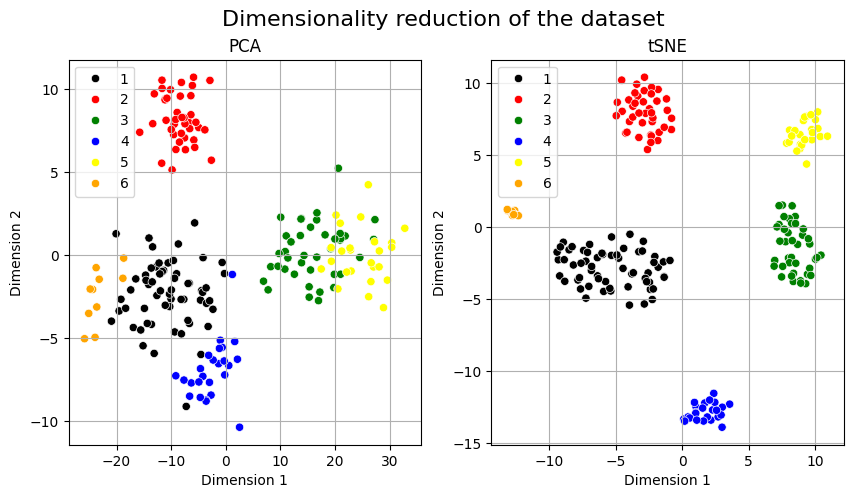

In [46]:
PCA_tSNE_visualization(X, 2, TRUElabels, PAL)

In [11]:
# [FROM SOLUTION OF LAB#4] THIS IS A **METHOD** THAT YOU CAN USE IN THE NEXT LAB SESSIONS TO find visualize data in 2D with clusters in different colours

def PCA_tSNE_visualization(data2visualize, NCOMP, LABELS, PAL):

  '''
  INPUT
  data2visualize    - data matrix to visualize
  NCOMP             - no. of components to decompose the dataset during PCA
  LABELS            - labels given by the clustering solution
  PAL               - palette of colours to distinguish between clusters
  '''

  '''
  OUTPUT
  Two figures: one using PCA and one using tSNE
  '''


  # PCA
  from sklearn.decomposition import PCA
  pca = PCA(n_components=NCOMP)
  pca_result = pca.fit_transform(data2visualize)
  print('PCA: explained variation per principal component: {}'.format(pca.explained_variance_ratio_.round(2)))

  # tSNE
  from sklearn.manifold import TSNE
  print('\nApplying tSNE...')
  np.random.seed(100)
  tsne = TSNE(n_components=2, verbose=0, perplexity=20, n_iter=300)
  tsne_results = tsne.fit_transform(data2visualize)


  # Plots
  fig1000 = plt.figure(figsize=(10,5))
  fig1000.suptitle('Dimensionality reduction of the dataset', fontsize=16)


  # Plot 1: 2D image of the entire dataset
  ax1 = fig1000.add_subplot(121)
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax1, hue=LABELS, palette=PAL)
  ax1.set_xlabel('Dimension 1', fontsize=10)
  ax1.set_ylabel('Dimension 2', fontsize=10)
  ax1.title.set_text('PCA')
  plt.grid()

  ax2= fig1000.add_subplot(122)
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax2, hue=LABELS, palette=PAL)
  ax2.set_xlabel('Dimension 1', fontsize=10)
  ax2.set_ylabel('Dimension 2', fontsize=10)
  ax2.title.set_text('tSNE')
  plt.grid()
  plt.show()